In [1]:
import sys
import os

# 0. Luôn đưa môi trường về thư mục gốc của Colab trước khi thao tác
%cd /content

# 1. Xóa bản cũ (dùng đường dẫn tuyệt đối để tránh xóa nhầm)
!rm -rf /content/BTL_ML

# 2. Clone bản mới nhất từ repo
!git clone https://github.com/VinhDoan1604/BTL_ML

# 3. Di chuyển vào thư mục dự án
%cd /content/BTL_ML

# 4. Thêm đường dẫn vào sys.path (có kiểm tra để tránh add trùng lặp path nếu chạy cell nhiều lần)
project_path = os.getcwd()
if project_path not in sys.path:
    sys.path.append(project_path)

# 5. Cài đặt các thư viện cần thiết
# !pip install -r requirements.txt

# 6. Kiểm tra lại xem mình đang đứng ở đâu và có những file gì
print("\n" + "="*40)
print("Thư mục hiện tại:", os.getcwd())
print("Danh sách file/thư mục:")
!ls

/content
Cloning into 'BTL_ML'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 13 (delta 3), reused 13 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 24.94 KiB | 2.77 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/BTL_ML

Thư mục hiện tại: /content/BTL_ML
Danh sách file/thư mục:
main.ipynb  src


In [2]:
!pip install "transformers<5.0.0" tf-keras tensorflow sentence-transformers torch langdetect emoji wordcloud

In [3]:
!pip install --upgrade nltk

In [4]:
import nltk

# Tải các gói dữ liệu cần thiết cho NLP của bạn
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import os
import time
import warnings
warnings.filterwarnings('ignore')

# --- 1. Thiết lập môi trường (Chạy trước khi gọi TensorFlow/Keras) ---
os.environ["TF_USE_LEGACY_KERAS"] = "1" # Ép dùng Keras 2 cho HuggingFace BERT

# --- 2. Core & Utilities ---
import string
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from collections import Counter

# --- 3. Visualization ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud

# --- 4. NLP & Text Processing ---
import re
import emoji
from langdetect import detect, LangDetectException, DetectorFactory
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

# Khởi tạo (nếu bạn cần gọi trực tiếp trong notebook)
DetectorFactory.seed = 0

# --- 5. Machine Learning (Scikit-Learn & SciPy) ---
from scipy.stats import spearmanr
from scipy.sparse import hstack, csr_matrix

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# --- 6. Deep Learning & Transformer Models ---
import tensorflow as tf
import tf_keras
from tf_keras.models import Sequential
from tf_keras.layers import Input, LSTM, SimpleRNN, Dense, Dropout, Embedding, TextVectorization
from tf_keras.callbacks import EarlyStopping

from sentence_transformers import SentenceTransformer
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer

# --- 7. Import các hàm từ Modules Local (src) ---
from src.cleaning import (
    clean_and_convert_labels,
    identify_language,
    perform_train_test_split
)

from src.preprocessing import (
    get_wordnet_pos,
    emoji_cleaning,
    delete_repeated_char,
    preprocess_and_tokenize
)

from src.models import (
    compute_comprehensive_metrics,
    balance_data,
    evaluate_model,
    CombinedExtractor,
    SklearnPipeline,
    LSTMPipeline,
    BERT_LSTMPipeline,
    TFBERTPipeline
)

from src.eda import (
    plot_label_distribution,
    create_text_features,
    plot_overall_text_features_distribution,
    plot_feature_distributions_by_label,
    print_detailed_statistics_by_label,
    plot_feature_trend_by_label,
    plot_emoji_analysis,
    plot_overall_top_words,
    get_ngram_description,
    get_ngram_filename_suffix,
    plot_top_words_by_label,
    plot_tfidf_features_per_class,
    get_vocab_set,
    jaccard,
    plot_jaccard_similarity_heatmap
)

In [6]:
import tensorflow as tf
import torch

# 1. Cấu hình GPU cho TensorFlow (Dùng cho LSTM và TFBERTPipeline)
tf_gpus = tf.config.list_physical_devices('GPU')
if tf_gpus:
    print(f"TENSORFLOW: Đã tìm thấy GPU.")
    # Bật tính năng Memory Growth: Chỉ cấp phát VRAM khi cần thiết
    try:
        for gpu in tf_gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Đã kích hoạt Memory Growth cho TensorFlow.")
    except RuntimeError as e:
        print("Lỗi khi cấu hình Memory Growth:", e)
else:
    print("TENSORFLOW: Không có GPU. Đang chạy bằng CPU.")

# 2. Cấu hình GPU cho PyTorch (Dùng cho SentenceTransformer/BERT Vector)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"PYTORCH: Đã tìm thấy GPU ({gpu_name}).")
else:
    print("PYTORCH: Không có GPU. Đang chạy bằng CPU.")

TENSORFLOW: Đã tìm thấy GPU.
Đã kích hoạt Memory Growth cho TensorFlow.
PYTORCH: Đã tìm thấy GPU (Tesla T4).


In [7]:
import kagglehub
shymammoth_shopee_reviews_path = kagglehub.dataset_download('shymammoth/shopee-reviews')

print('Data source import complete.')


Using Colab cache for faster access to the 'shopee-reviews' dataset.
Data source import complete.


# Loading data

In [8]:
DATA_PATH = shymammoth_shopee_reviews_path + "/shopee_reviews.csv"

print("Loading dataset...")
df = pd.read_csv(DATA_PATH)

# Randomly sample 100,000 rows
df = df.sample(frac=100_000/len(df), random_state=42).reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")

Loading dataset...
Sampled dataset shape: (100000, 2)


In [9]:
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

# Cleaning data

## Resolving Data Type Heterogeneity in Target Labels ##

In [10]:
print("="*45)
print("-------- Unique labels --------")
print(df[LABEL_COLUMN].value_counts())
print("="*45)
print("-------- Checking types --------")
print(df[LABEL_COLUMN].apply(type).value_counts())
print("="*45)

-------- Unique labels --------
label
5        75742
5        11213
4         5823
3         2715
1         1674
2         1101
4          901
3          433
1          255
2          142
label        1
Name: count, dtype: int64
-------- Checking types --------
label
<class 'int'>    87055
<class 'str'>    12945
Name: count, dtype: int64


In [11]:
df = clean_and_convert_labels(df)

--- Unique values in 'label' before conversion ---
label
5        75742
5        11213
4         5823
3         2715
1         1674
2         1101
4          901
3          433
1          255
2          142
label        1
Name: count, dtype: int64
Non-numeric values found: ['label']

Final Data Type: int64
--- Unique values in 'label' after conversion ---
label
5    86955
4     6724
3     3148
1     1929
2     1243
Name: count, dtype: int64


--- [STATUS] Initializing Full-Scale Corpus Analysis ---


Identifying Languages:   0%|          | 0/99999 [00:00<?, ?it/s]

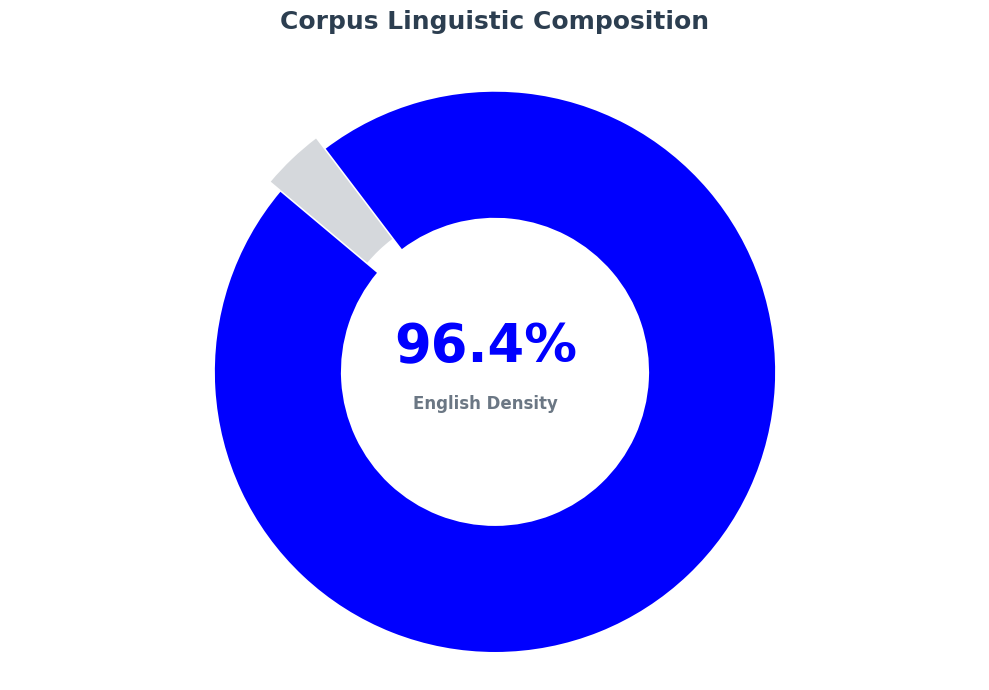


[ACTION] English dominance detected (> 90.0%). Isolating primary corpus...
Filtration successful. Current Dimension: 96440 rows.
[CLEANUP] Internal feature 'lang' decommissioned.
--- [STATUS] Pipeline Execution Completed ---


In [12]:
DetectorFactory.seed = 42
tqdm.pandas(desc="Identifying Languages")

print("--- [STATUS] Initializing Full-Scale Corpus Analysis ---")
original_row_count = len(df)

# 1. Processing: Language identification on the entire Dataset
# We skip the sampling step to ensure the integrity of the input data
df['lang'] = df['text'].fillna('').astype(str).progress_apply(identify_language)

# 2. Statistical Distribution: Calculate distribution ratio
lang_stats = df['lang'].value_counts(normalize=True).mul(100).round(2)
en_ratio = lang_stats.get('en', 0)
others_ratio = 100 - en_ratio

fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

# Draw Donut chart
wedges, _ = ax.pie(
    [en_ratio, others_ratio],
    colors=['blue', '#D5D8DC'], # Changed color from colors[0] to 'blue'
    startangle=140,
    wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 0},
    explode=(0.05, 0)
)

# Add KPI to the center of the circle (Central Metric)
ax.text(0, 0.05, f"{en_ratio:.1f}%", ha='center', va='center',
        fontsize=38, fontweight='bold', color='blue') # Changed color from colors[0] to 'blue'
ax.text(0, -0.15, "English Density", ha='center', va='center',
        fontsize=12, color='#2C3E50', fontweight='semibold', alpha=0.7)

# Title and In-depth Description (Description)
plt.title('Corpus Linguistic Composition', fontsize=18, pad=25, fontweight='bold', color='#2C3E50')

plt.axis('equal')
plt.tight_layout()
plt.show()

# 4. Automated Filtration: Filter data based on statistical threshold
STRICT_THRESHOLD = 90.0
is_dominant = en_ratio > STRICT_THRESHOLD

if is_dominant:
    print(f"\n[ACTION] English dominance detected (> {STRICT_THRESHOLD}%). Isolating primary corpus...")
    df = df[df['lang'] == 'en'].reset_index(drop=True)
    print(f"Filtration successful. Current Dimension: {len(df)} rows.")
else:
    print(f"\n[OBSERVATION] Multilingual distribution detected. Maintaining 'lang' feature for stratified analysis.")

# Memory cleanup: Remove intermediate column after Feature Engineering is complete
if 'lang' in df.columns:
    df = df.drop('lang', axis=1)
    print("[CLEANUP] Internal feature 'lang' decommissioned.")

print("--- [STATUS] Pipeline Execution Completed ---")

In [13]:
X_train, X_test, y_train, y_test = perform_train_test_split(df, LABEL_COLUMN, test_size=0.20, random_state=42)

# EDA

In [14]:
df_eda = X_train.copy()
df_eda[LABEL_COLUMN] = y_train.copy()

In [15]:
print("="*45)
print("Shape:", df.shape)

print("="*45)
print("Columns:", df.columns.tolist())

print("="*45)
print(f'Dtypes:\n{df.dtypes}')

print("="*45)
print(f'Info:')
df.info()

print("="*45)
print(f'Null values:\n{df.isnull().sum()}')

print("="*45)
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df['text'].duplicated().sum())

print("="*45)
print("Sample:")
df_eda.head(10)

Shape: (96440, 2)
Columns: ['label', 'text']
Dtypes:
label     int64
text     object
dtype: object
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96440 entries, 0 to 96439
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   96440 non-null  int64 
 1   text    96440 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB
Null values:
label    0
text     0
dtype: int64
Duplicate rows: 0
Duplicate texts: 0
Sample:


,text,label
51368,Nice and really can fit my 10mnth and 5yr old....,5
89524,"Bought 3 masks, navy mask is dirty, burgundy m...",3
25553,Item received in good packaging and condition....,5
28195,Quality is very good for price paid. Will defi...,5
1457,Love this casing and the strap! Very useful wh...,5
35397,"Rather fast delivery, ordered on 15jan, receiv...",5
43266,Looks good. Magnet is strong too! Has the adhe...,5
8625,Good product and worth the money to pay for. D...,5
9913,"Received it fast! Yet to try, cant wait to try...",5
64405,Ordered on 23 Mar and received on 27 Mar. Deli...,5


In [16]:
LABEL_ORDER = sorted(df['label'].unique())
LABEL_COUNT= len(LABEL_ORDER)

theme_palette='inferno'
colors = sns.color_palette(theme_palette, LABEL_COUNT).as_hex()

print(LABEL_ORDER)

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


## Target Class Frequency & Prevalence Profiling ##

Total  count:  77152


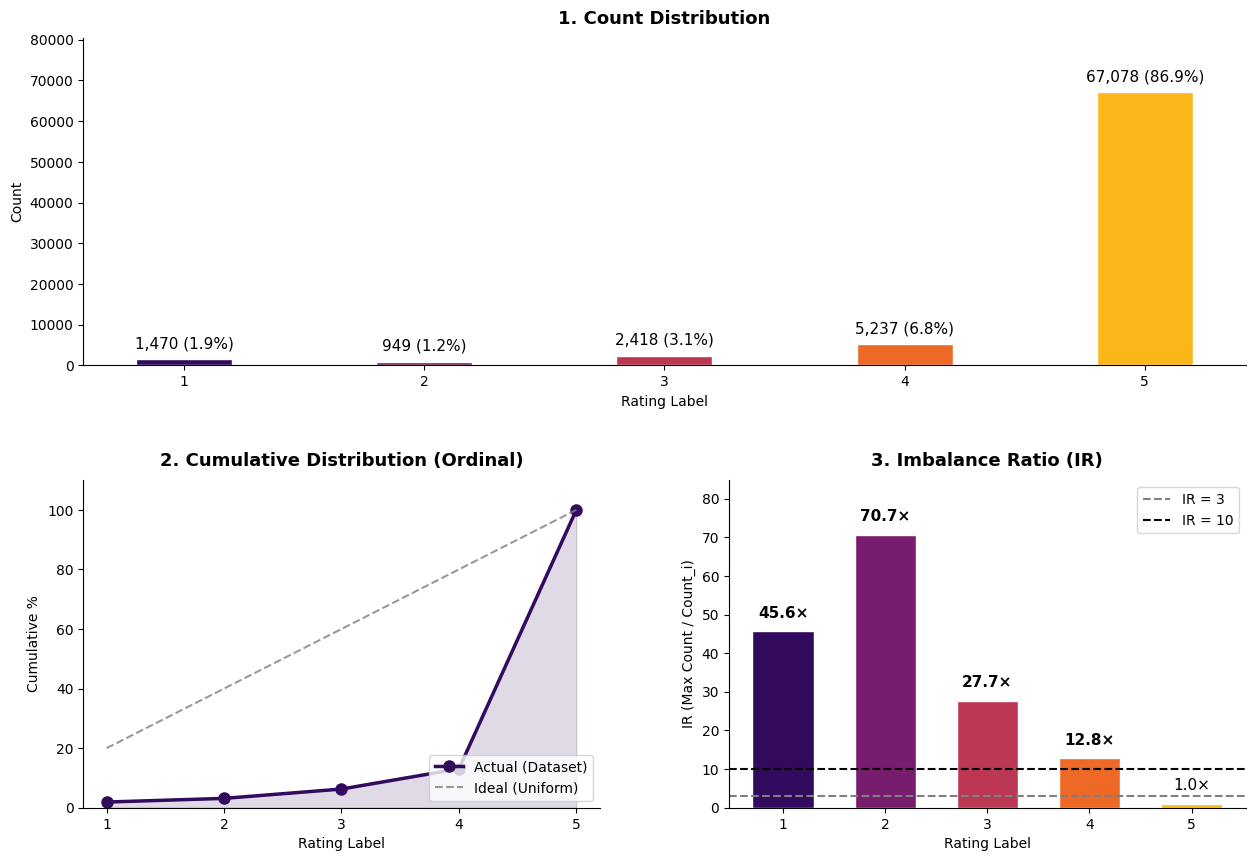

In [17]:
plot_label_distribution(df_eda, LABEL_COLUMN, LABEL_ORDER, colors, theme_palette)

## Quantitative Textual Patterns ##

In [18]:
# Execution example (Replace 'text' with your actual column name)
df_eda=create_text_features(df_eda)

Feature extraction completed successfully.


In [19]:
df.head(10)

,label,text
0,5,Love these masks and samples given. Will try o...
1,5,Good value for 300g tube. Thank you !
2,5,Ordered a Size 12 but came a Size 9 so I’m not...
3,5,Ordered on 3/11/19 received item in good condi...
4,5,Super comfy.....love it.....
5,5,Item was in great condition. Super fast delive...
6,5,Good fast and efficient.. recommended.
7,4,difficult to apply on phone due to many air bu...
8,4,"It’s not a silent keyboard, the letter “T” is ..."
9,5,It is worth the money! And delivered within th...


In [20]:
features=['n_words', 'num_emoji', 'upper_ratio']

## Quantitative Analysis of Review Length ##

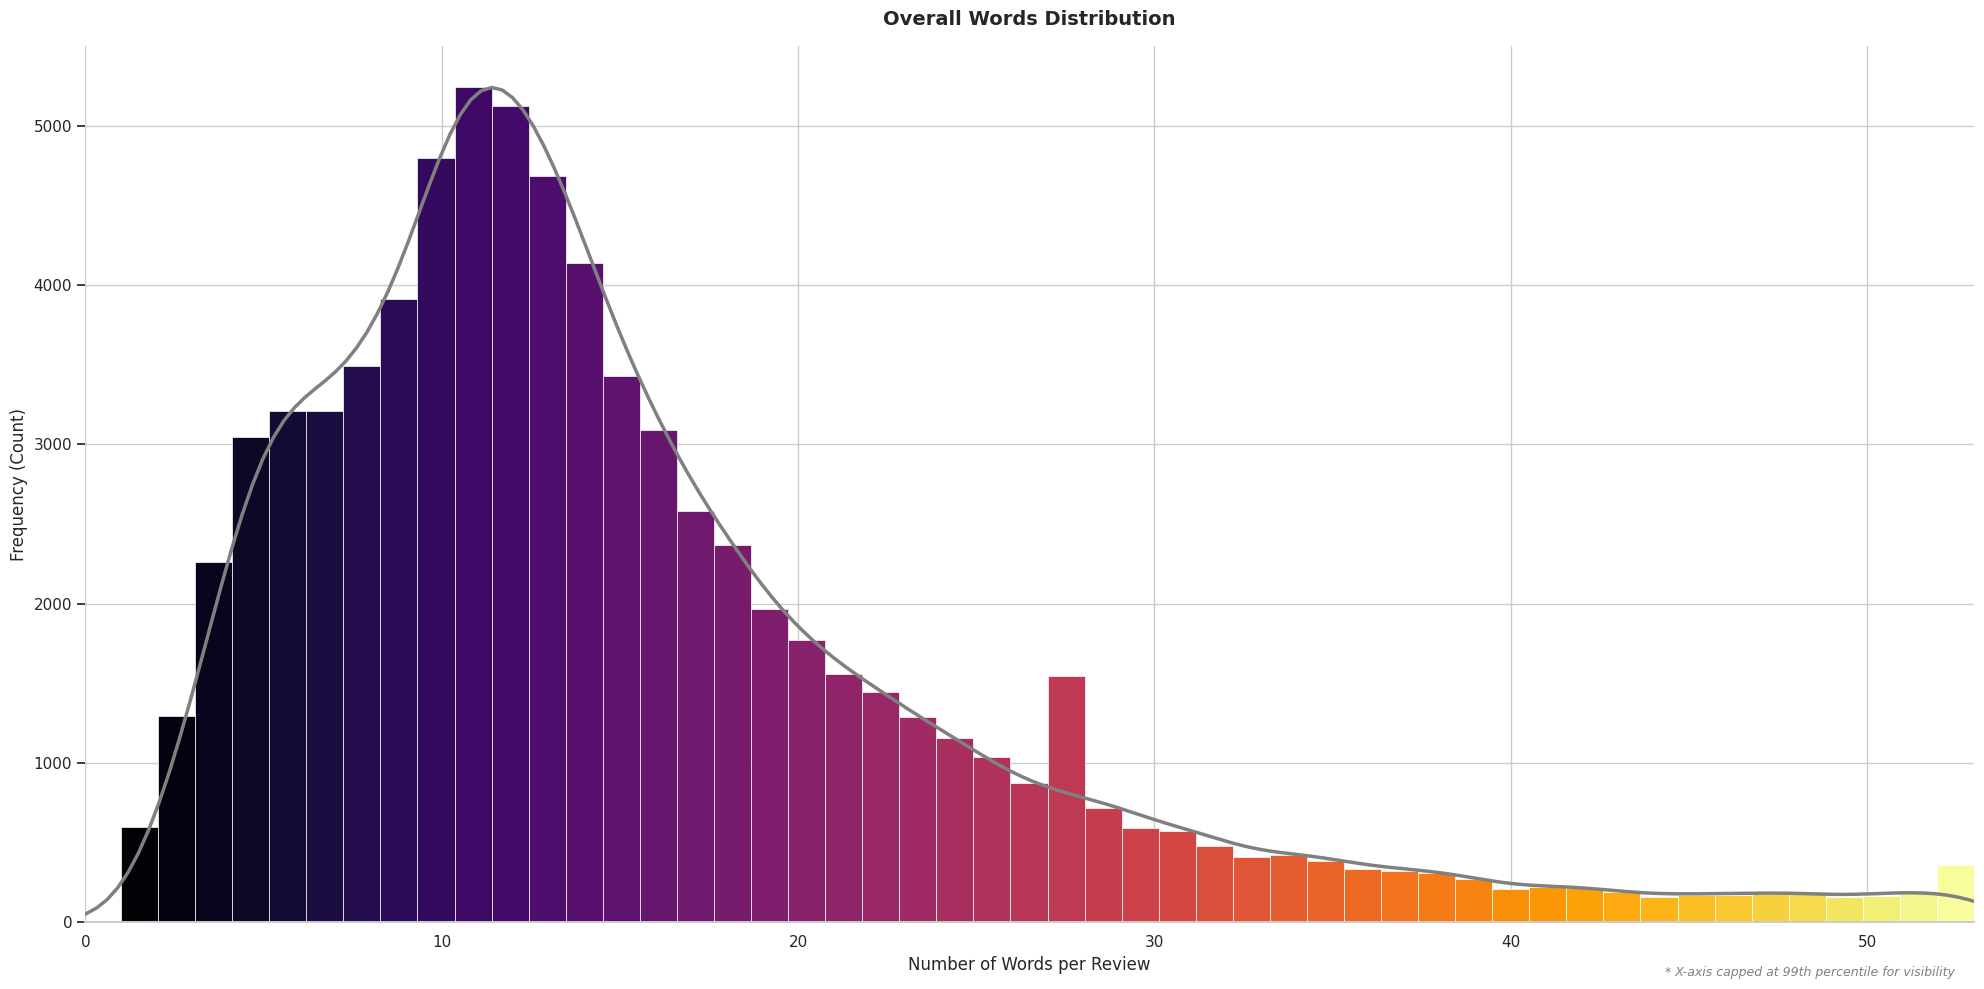

In [21]:
# Call the new function for 'n_words' and 'n_chars'
plot_overall_text_features_distribution(df_eda, ['n_words'], theme_palette)

## Across Labels

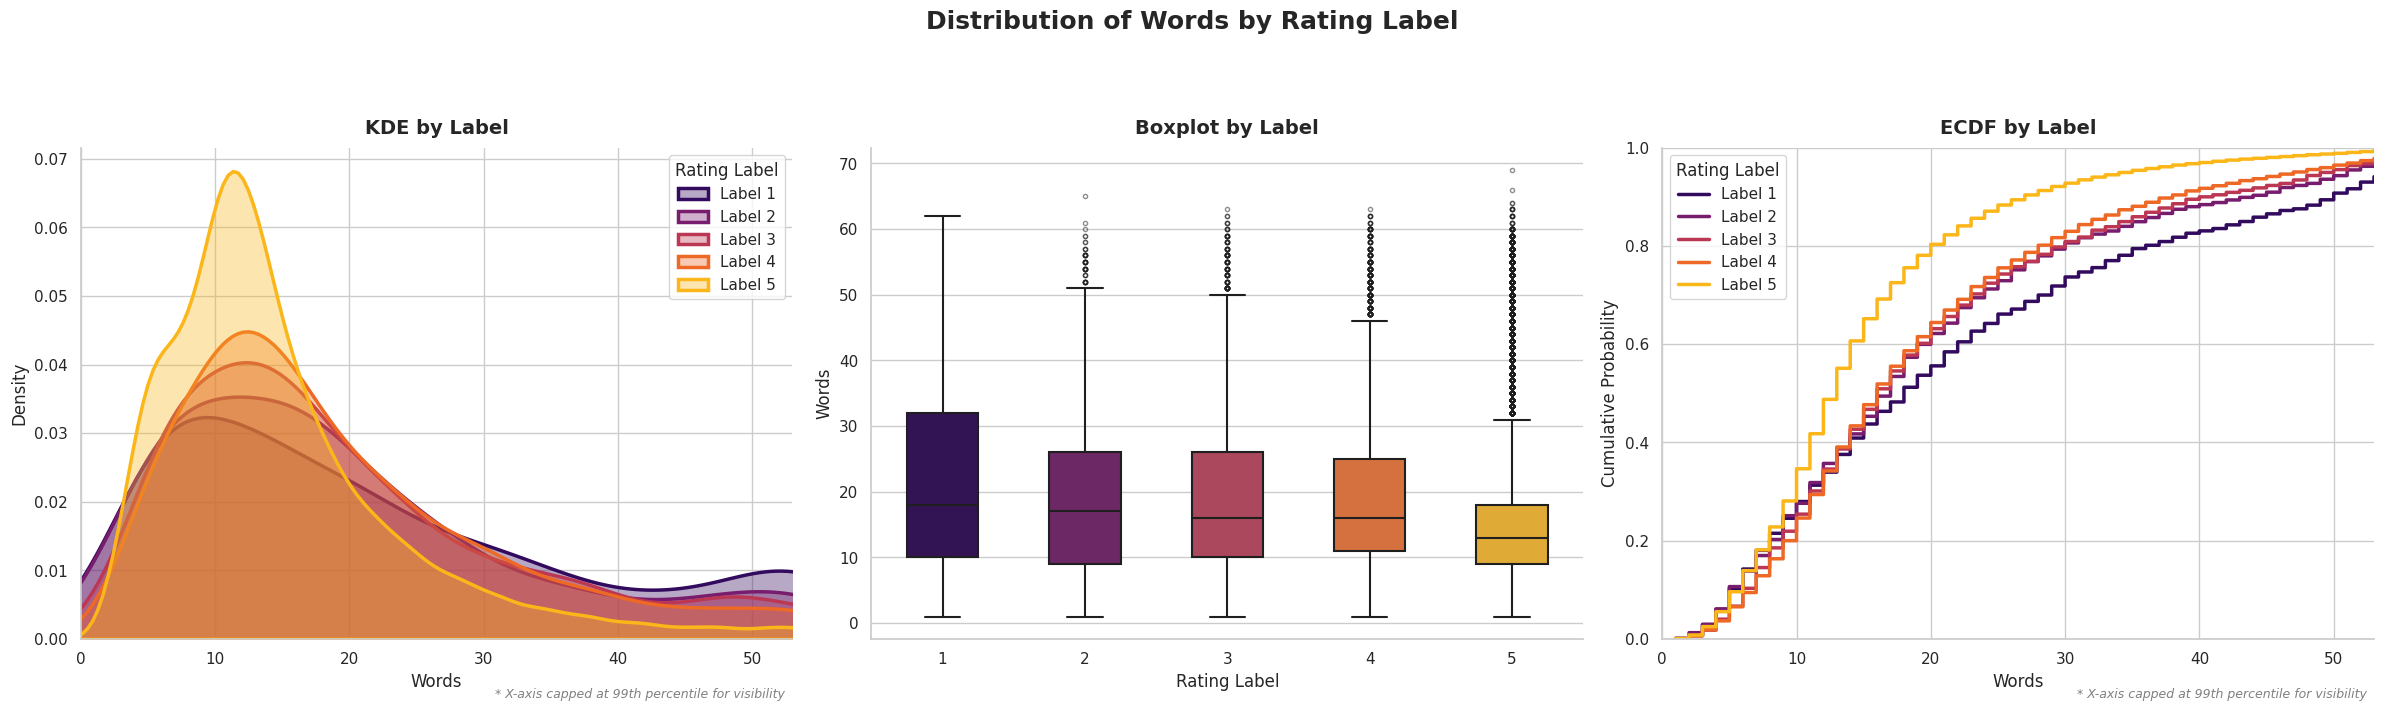

In [22]:
# --- Call the new combined plotting function for 'n_words' ---
plot_feature_distributions_by_label(
    df=df_eda,
    feature_col='n_words',
    label_column=LABEL_COLUMN,
    label_order=LABEL_ORDER,
    theme_palette=theme_palette
)

In [23]:
# Call the new function with your dataframe and relevant variables
print_detailed_statistics_by_label(df_eda, LABEL_COLUMN, ['n_words'])


--- Detailed Statistics per Rating Label (n_words & n_chars) ---

--- Words Statistics ---
        mean  median  min  max    std
label                                
1      22.43    18.0    1   62  15.82
2      20.17    17.0    1   65  13.96
3      20.02    16.0    1   63  13.31
4      19.48    16.0    1   63  12.49
5      15.02    13.0    1   69   9.54




## Spearman correlation ##

Spearman correlation with labels:
  n_words               r = -0.129  ***
  num_emoji             r = +0.060  ***
  upper_ratio           r = +0.100  ***


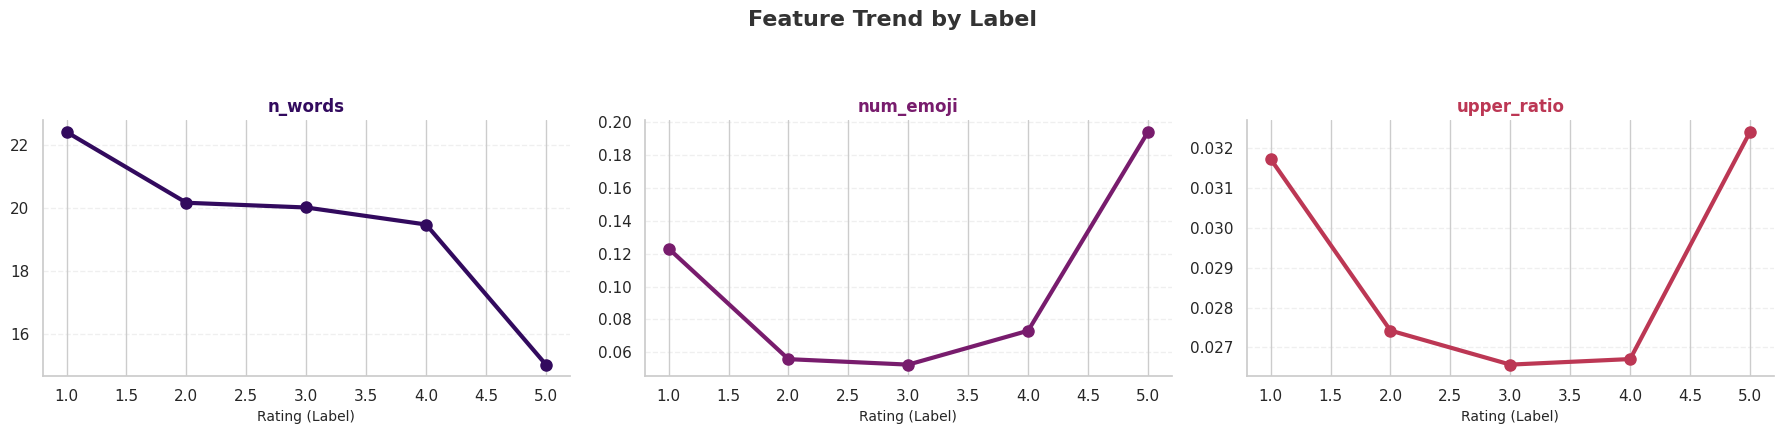

In [24]:
# Call the new function with your dataframe and relevant variables
plot_feature_trend_by_label(df_eda, features, LABEL_COLUMN, LABEL_ORDER, colors)

## Emoji ##

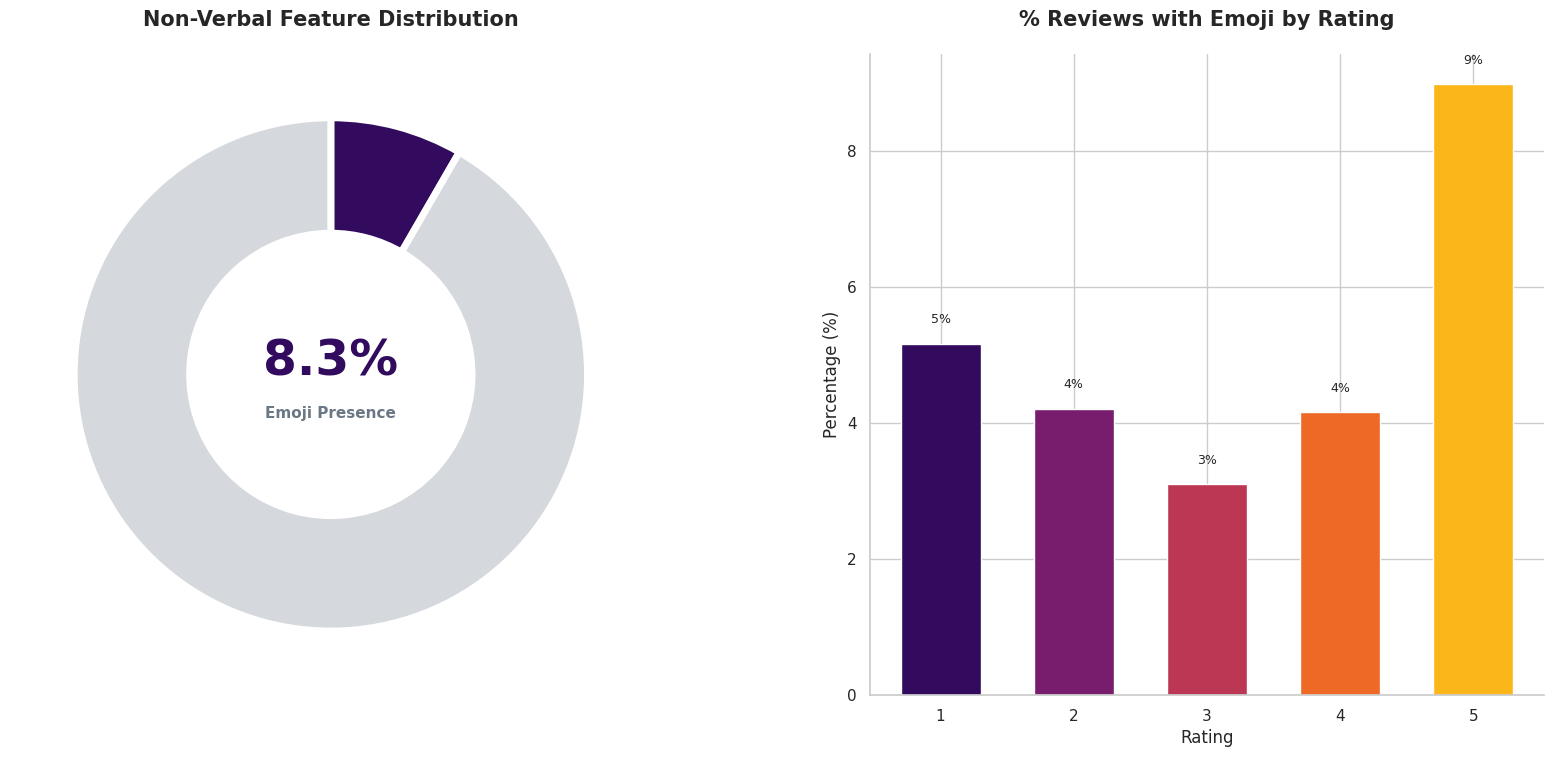

In [25]:
plot_emoji_analysis(df_eda, TEXT_COLUMN, LABEL_COLUMN, LABEL_ORDER, colors)

# Preprocessing

In [26]:
X_train_features = create_text_features(X_train, text_col='text')
X_test_features = create_text_features(X_test, text_col='text')

Feature extraction completed successfully.
Feature extraction completed successfully.


In [27]:
# Initialize Lemmatizer (Should be outside the function to avoid reloading multiple times, which speeds up apply operations on DataFrame)
lemmatizer = WordNetLemmatizer()

X_train_features['processed_text'] = X_train_features[TEXT_COLUMN].apply(preprocess_and_tokenize)
X_test_features['processed_text'] = X_test_features[TEXT_COLUMN].apply(preprocess_and_tokenize)

In [28]:
df_eda = X_train_features.copy()
df_eda['label'] = y_train

## Global top words ##

EDA: GLOBAL BAG OF WORDS FREQUENCY


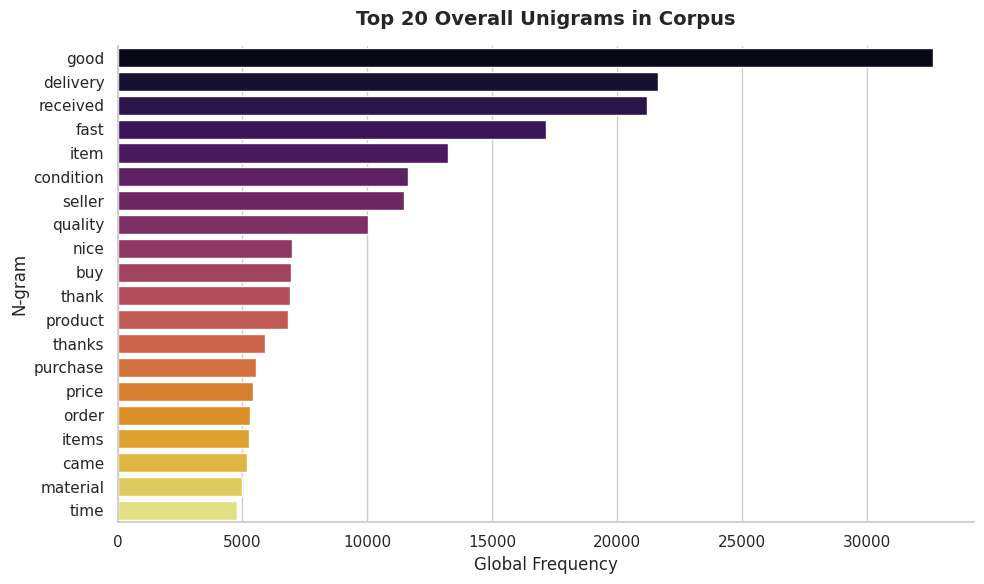

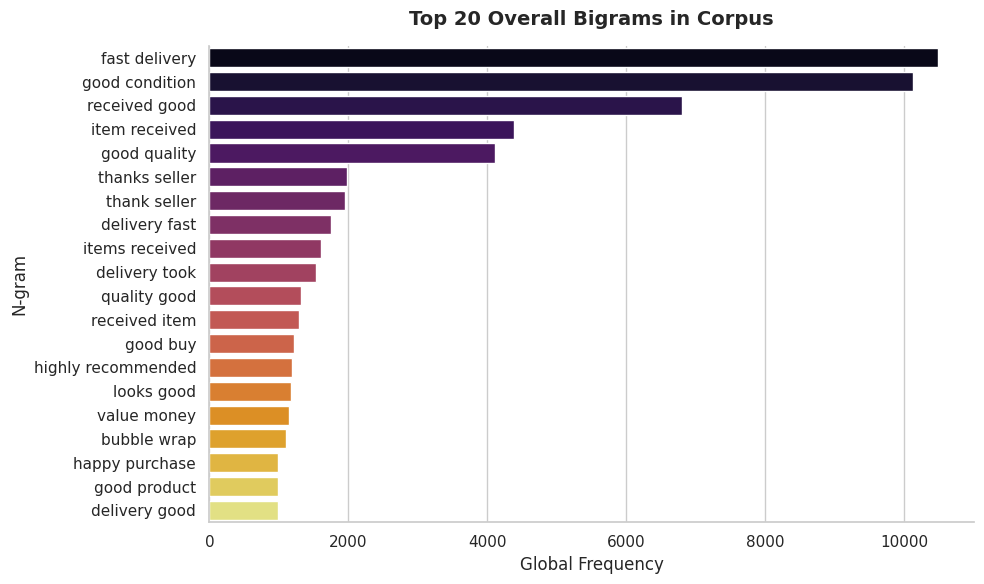

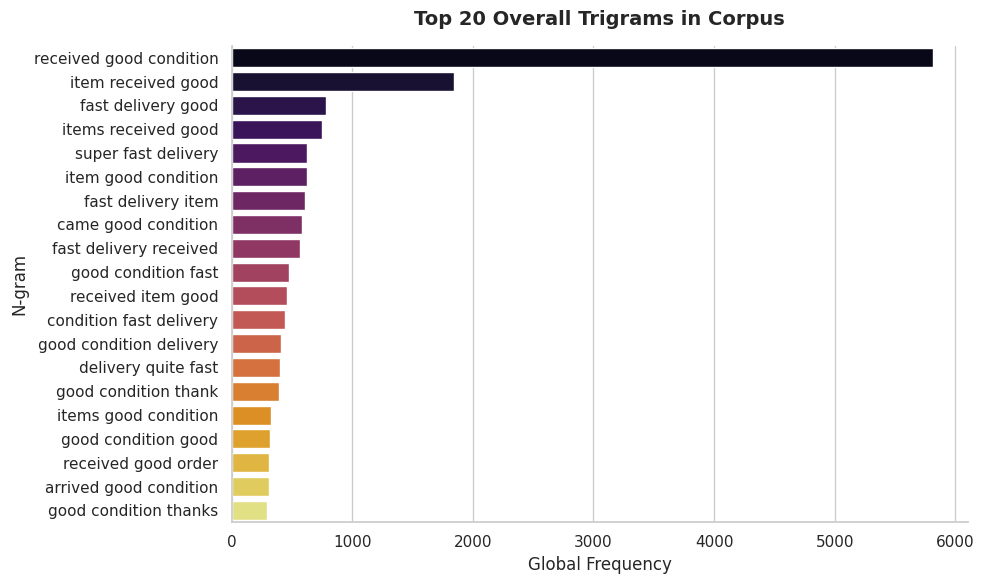

In [29]:
# --- GỌI HÀM THỰC THI (EDA GLOBAL BAG OF WORDS) ---

print("="*50)
print("EDA: GLOBAL BAG OF WORDS FREQUENCY")
print("="*50)

# Chạy cho Unigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(1, 1), title="Unigrams")

# Chạy cho Bigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(2, 2), title="Bigrams")

# Chạy cho Trigram
plot_overall_top_words(df_eda, 'processed_text', top_n=20, ngram_range=(3, 3), title="Trigrams")

## Class-Specific Top Words

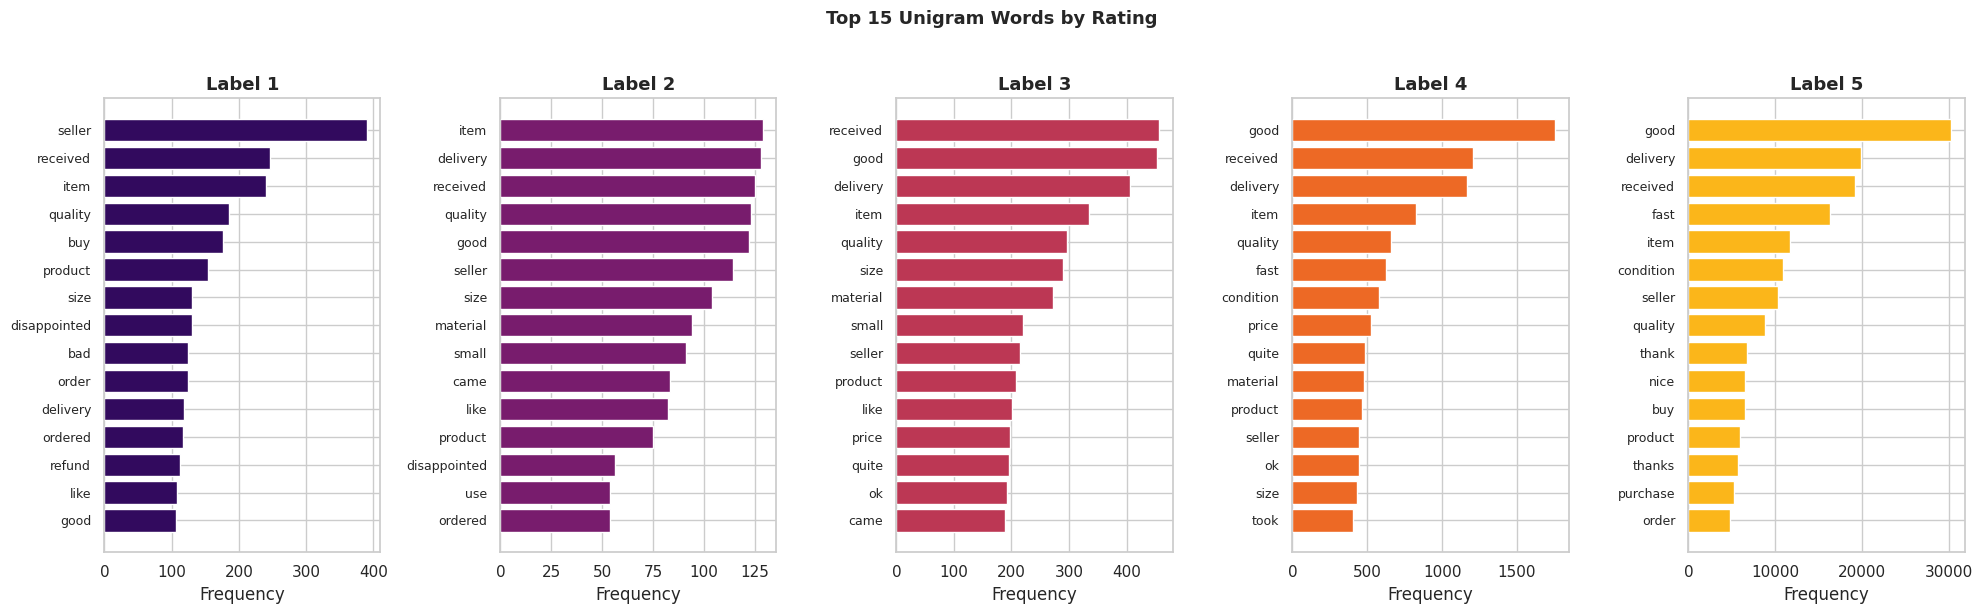

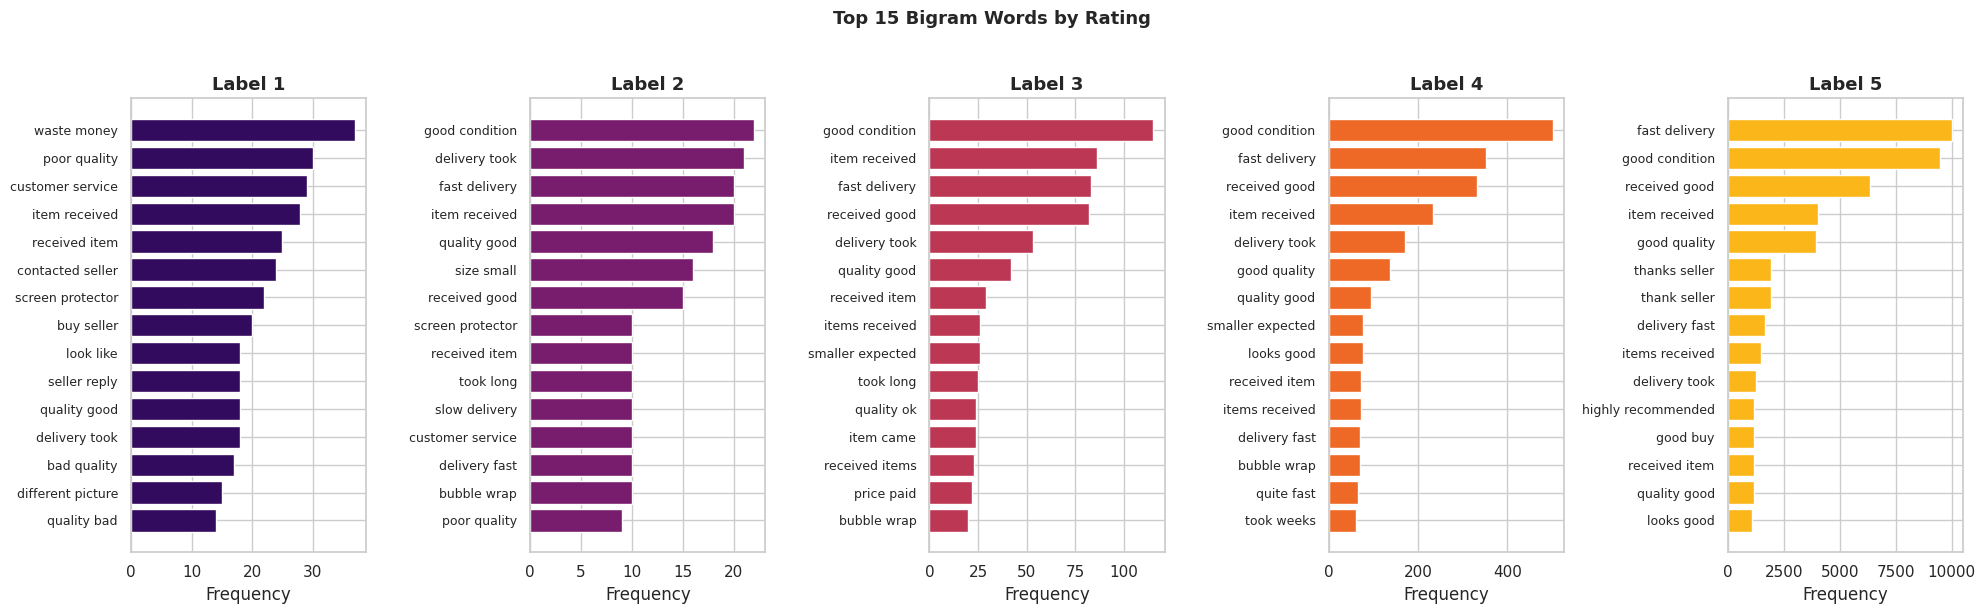

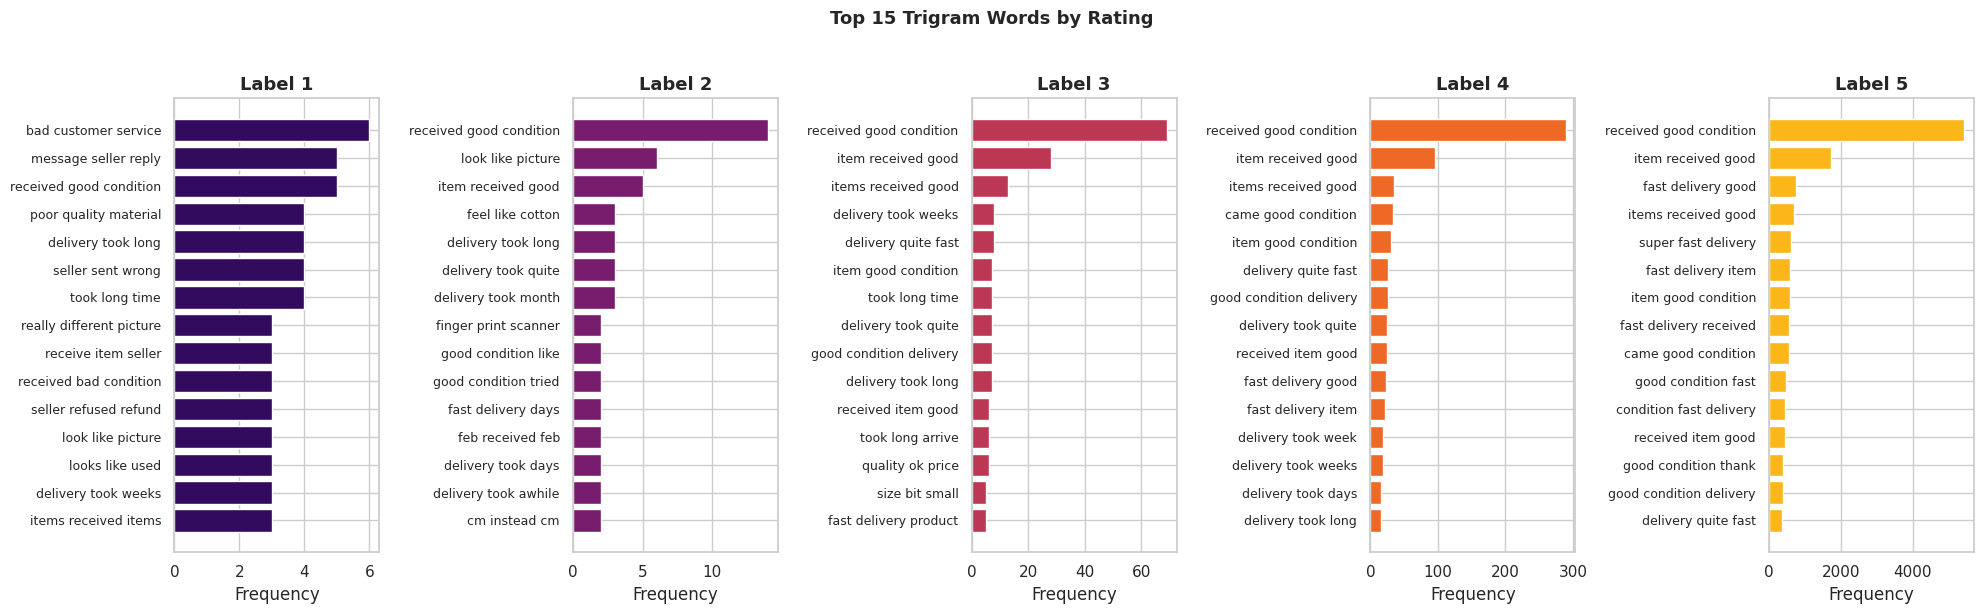

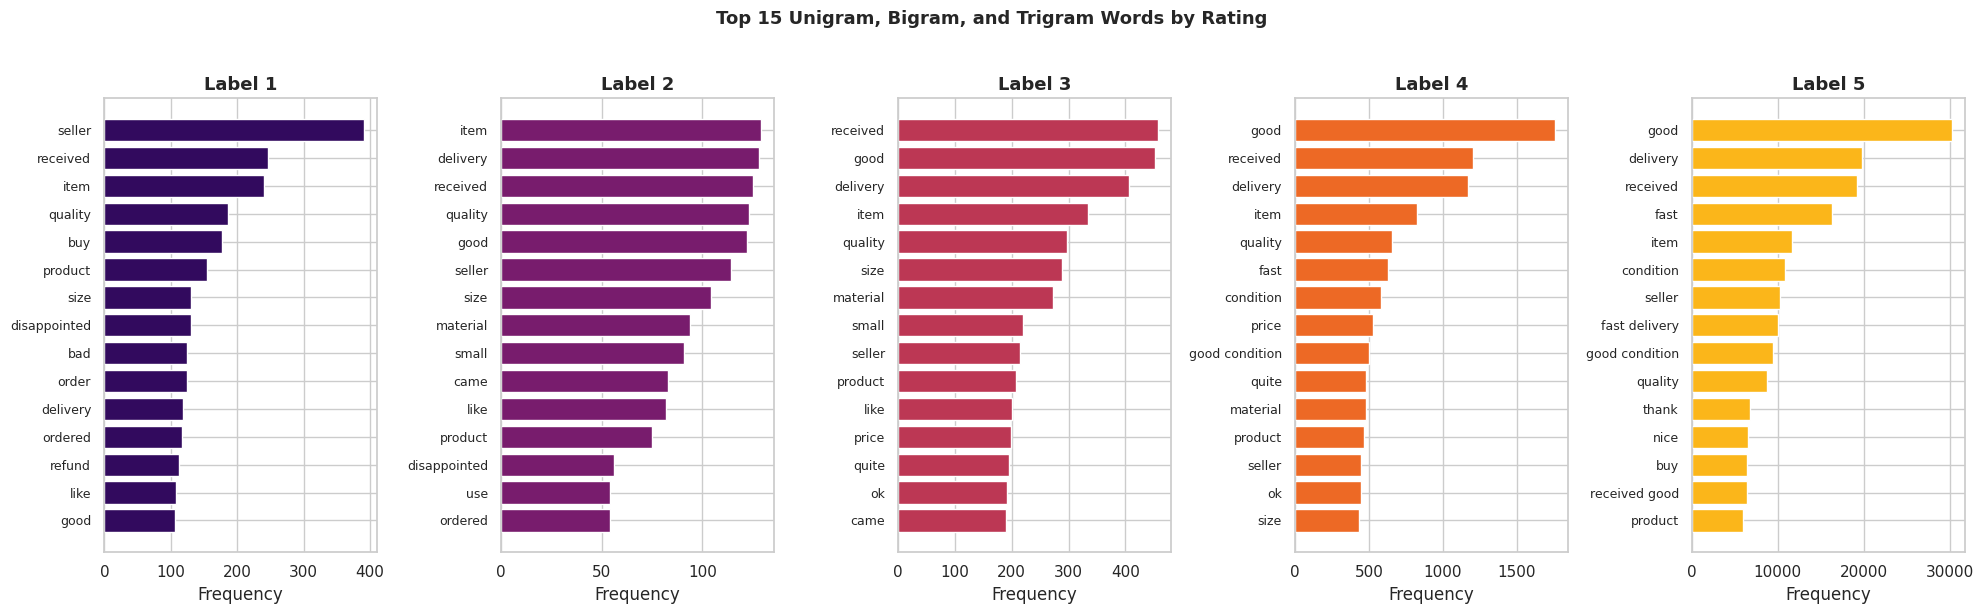

In [30]:
# Unigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(1,1))

# Bigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(2,2))

# Trigram
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(3,3))

# Unigram, Bigram, and Trigram combined
plot_top_words_by_label(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, top_n=15, ngram_range=(1,3))

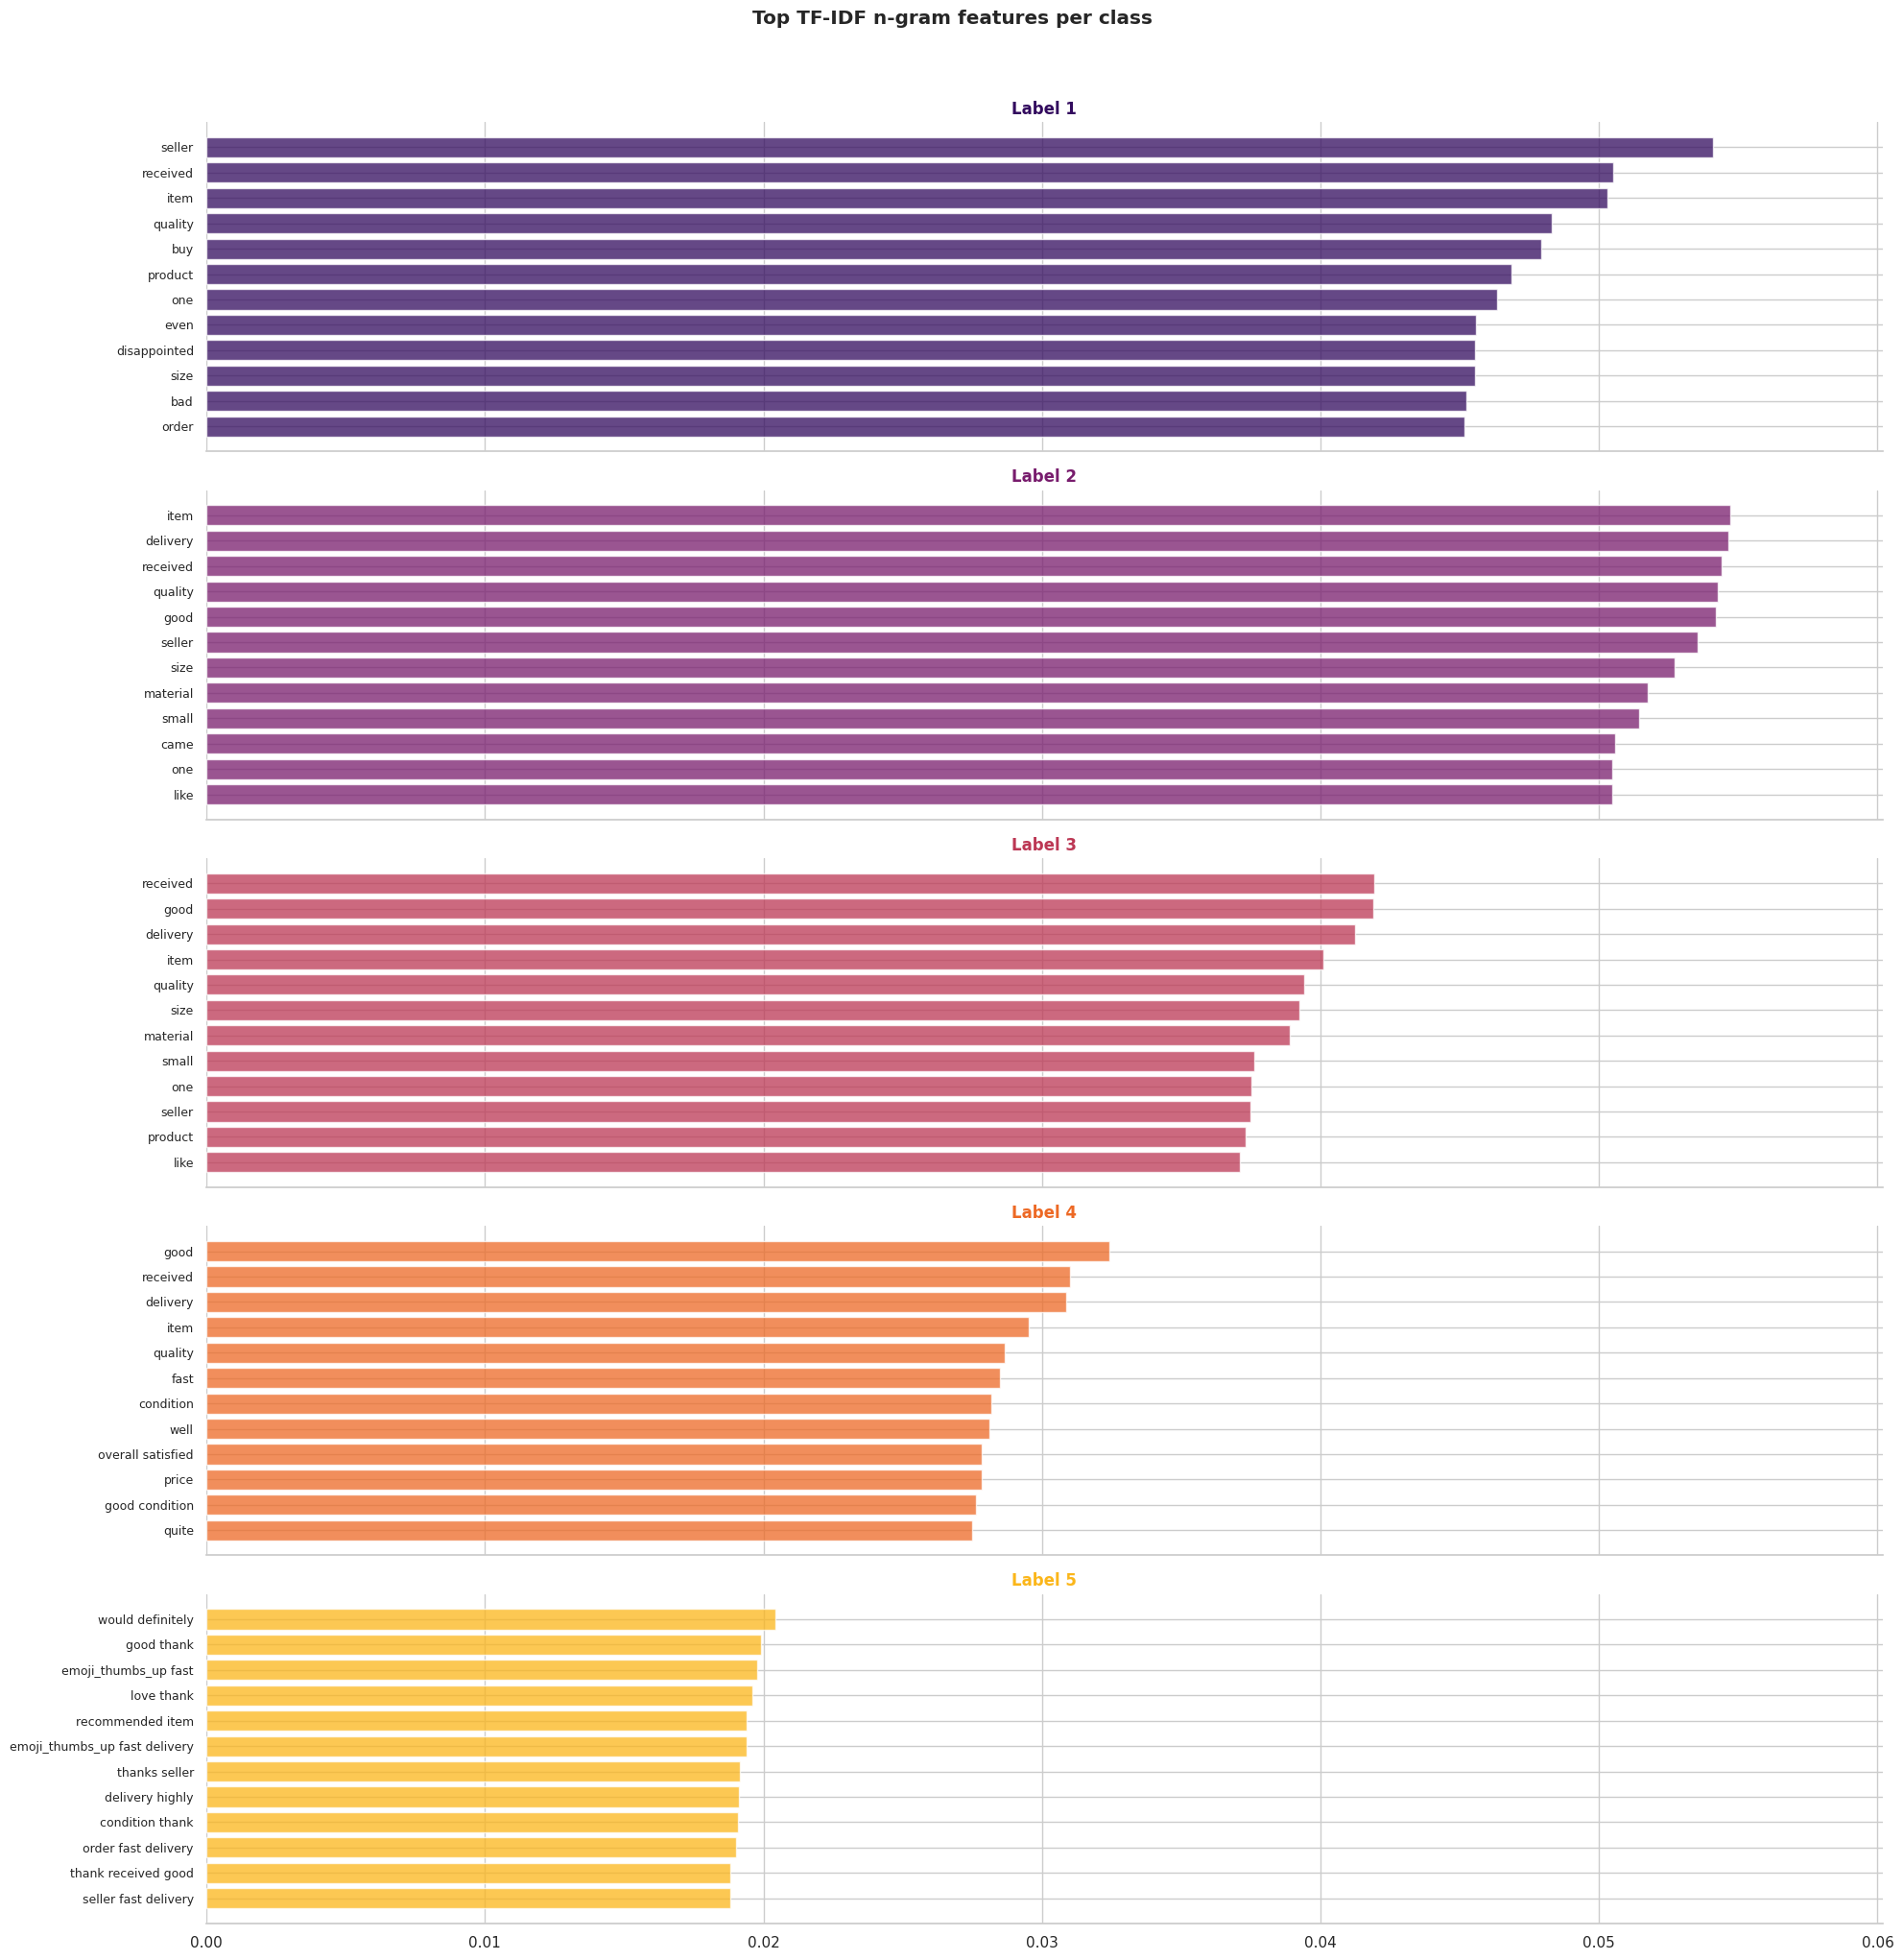

In [31]:
# Call the new function with your dataframe and relevant variables
plot_tfidf_features_per_class(df_eda, 'processed_text', LABEL_COLUMN, LABEL_ORDER, colors, theme_palette)

## Ordinal analysis

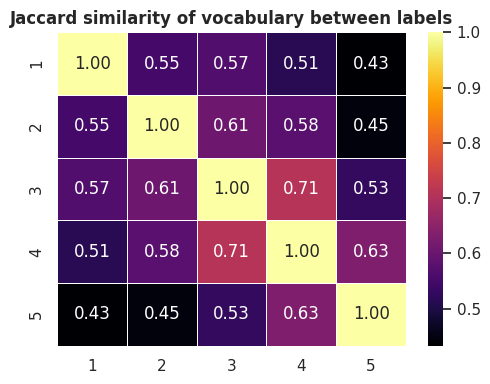

Adjacent labels have high Jaccard similarity → high adjacent confusion → should use ordinal-aware evaluation


In [32]:
# Call the new function with your dataframe and relevant variables
plot_jaccard_similarity_heatmap(df_eda, LABEL_COLUMN, LABEL_ORDER, theme_palette)

# Data Splitting & Pipeline Architecture

In [33]:
df_train = X_train_features.copy()
df_train['label'] = y_train.values # Gộp y vào để balance_data có thể hoạt động

df_test = X_test_features.copy()
df_test['label'] = y_test.values   # Khởi tạo df_test cho Lỗi 4

# 2. Tạo tập validation từ tập train (cho Lỗi 1)
from sklearn.model_selection import train_test_split

df_train, df_val, y_train, y_val = train_test_split(
    df_train,
    df_train['label'],
    test_size=0.1,
    random_state=42,
    stratify=df_train['label']
)

In [ ]:
extractors = {
    "BoW (1-3 gram)": {
        "ext": CountVectorizer(ngram_range=(1, 3), max_features=10000),
        "scaler": MaxAbsScaler()
    },
    "TF-IDF (1-3 gram)": {
        "ext": TfidfVectorizer(ngram_range=(1, 3), max_features=10000),
        "scaler": MaxAbsScaler()
    },
    "BERT Vector": {
        "ext": SentenceTransformer('all-MiniLM-L6-v2'),
        "scaler": MinMaxScaler()
    },
    "Hybrid (TF-IDF + BERT)": {
        "ext": CombinedExtractor(max_features=5000),
        "scaler": MaxAbsScaler()
    }
}

models = {
    "LogReg": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "NaiveBayes": MultinomialNB()
}

experiments = {}
exp_counter = 1

# Sinh tổ hợp
for ext_name, config in extractors.items():
    for mod_name, model in models.items():
        if ext_name == "Hybrid (TF-IDF + BERT)" and mod_name == "NaiveBayes":
            continue

        experiments[f"{exp_counter}. {ext_name} + {mod_name} (Class Weights)"] = SklearnPipeline(
            extractor=config["ext"],
            model=model,
            text_col='text' if "BERT" in ext_name else 'processed_text',
            scaler=config["scaler"]
        )
        exp_counter += 1

# Deep Learning Pipelines
experiments[f"{exp_counter}. LSTM Deep Learning (Class Weights)"] = LSTMPipeline(
    max_vocab=15000, max_len=100, text_col='text' # Đổi sang văn bản thô cho LSTM
)
exp_counter += 1

experiments[f"{exp_counter}. DistilBERT Fine-Tuning (Class Weights)"] = TFBERTPipeline(
    model_name='distilbert-base-uncased', max_len=128, text_col='text'
)

experiments[f"{exp_counter}. BERT Sequence + LSTM (Class Weights)"] = BERT_LSTMPipeline(
    model_name='distilbert-base-uncased', max_len=128, text_col='text'
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Bắt đầu chạy mới hoàn toàn.
Tổng số tổ hợp cần huấn luyện: 9

 ĐANG HUẤN LUYỆN: [ 1. BoW (1-3 gram) + LogReg (Class Weights) ]...

MODEL RESULTS: 1. BoW (1-3 gram) + LogReg (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.25      0.53      0.34       367
           2       0.07      0.18      0.10       237
           3       0.10      0.25      0.15       605
           4       0.14      0.33      0.20      1310
           5       0.95      0.76      0.85     16769

    accuracy                           0.71     19288
   macro avg       0.30      0.41      0.33     19288
weighted avg       0.85      0.71      0.76     19288



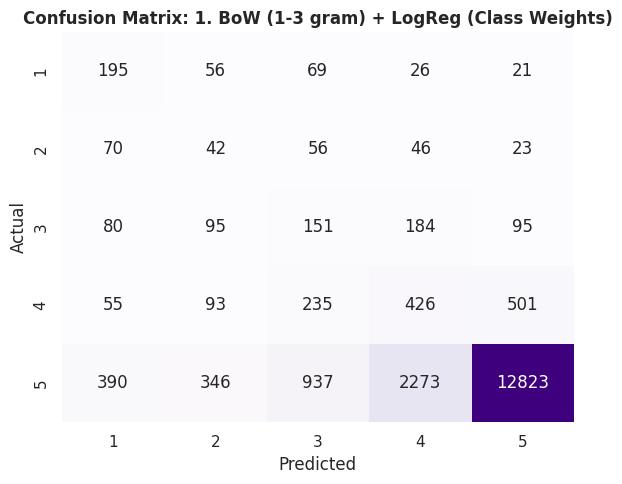

 Đã lưu tiến trình cho: 1. BoW (1-3 gram) + LogReg (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 2. BoW (1-3 gram) + NaiveBayes (Class Weights) ]...

MODEL RESULTS: 2. BoW (1-3 gram) + NaiveBayes (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.42      0.38      0.40       367
           2       0.04      0.00      0.01       237
           3       0.15      0.13      0.14       605
           4       0.21      0.25      0.23      1310
           5       0.91      0.92      0.92     16769

    accuracy                           0.83     19288
   macro avg       0.35      0.34      0.34     19288
weighted avg       0.82      0.83      0.83     19288



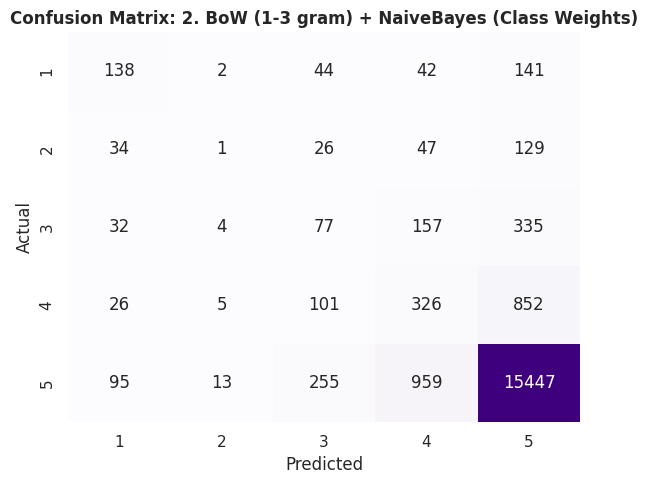

 Đã lưu tiến trình cho: 2. BoW (1-3 gram) + NaiveBayes (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 3. TF-IDF (1-3 gram) + LogReg (Class Weights) ]...

MODEL RESULTS: 3. TF-IDF (1-3 gram) + LogReg (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.25      0.51      0.34       367
           2       0.07      0.19      0.10       237
           3       0.10      0.26      0.15       605
           4       0.15      0.35      0.21      1310
           5       0.96      0.76      0.84     16769

    accuracy                           0.70     19288
   macro avg       0.31      0.41      0.33     19288
weighted avg       0.85      0.70      0.76     19288



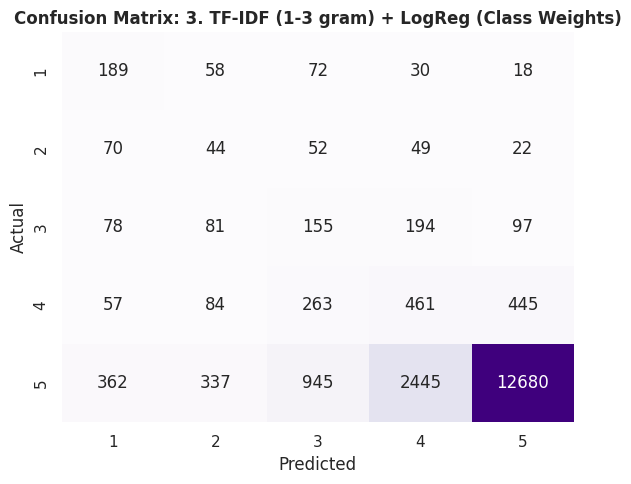

 Đã lưu tiến trình cho: 3. TF-IDF (1-3 gram) + LogReg (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 4. TF-IDF (1-3 gram) + NaiveBayes (Class Weights) ]...

MODEL RESULTS: 4. TF-IDF (1-3 gram) + NaiveBayes (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.58      0.25      0.35       367
           2       0.00      0.00      0.00       237
           3       0.18      0.05      0.08       605
           4       0.22      0.16      0.19      1310
           5       0.90      0.96      0.93     16769

    accuracy                           0.85     19288
   macro avg       0.38      0.29      0.31     19288
weighted avg       0.81      0.85      0.83     19288



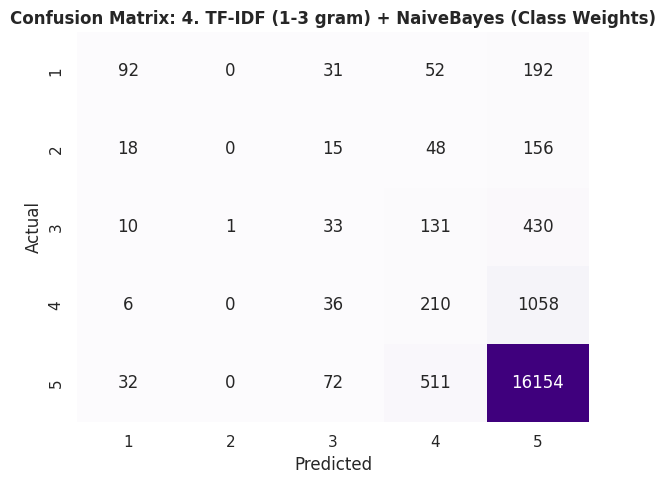

 Đã lưu tiến trình cho: 4. TF-IDF (1-3 gram) + NaiveBayes (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 5. BERT Vector + LogReg (Class Weights) ]...

MODEL RESULTS: 5. BERT Vector + LogReg (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.21      0.53      0.30       367
           2       0.06      0.25      0.10       237
           3       0.11      0.28      0.16       605
           4       0.14      0.37      0.20      1310
           5       0.97      0.71      0.82     16769

    accuracy                           0.66     19288
   macro avg       0.30      0.43      0.32     19288
weighted avg       0.86      0.66      0.74     19288



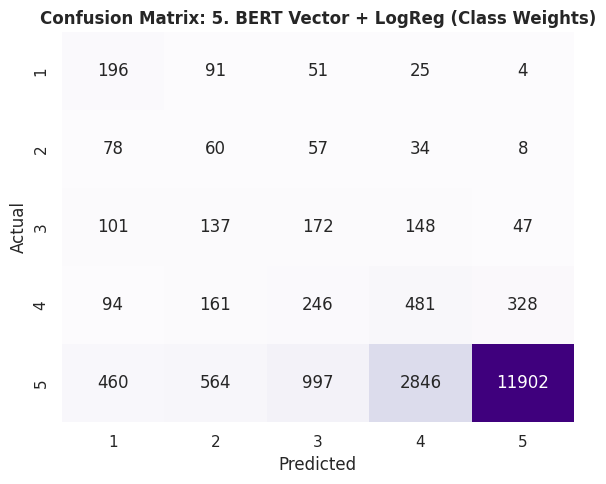

 Đã lưu tiến trình cho: 5. BERT Vector + LogReg (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 6. BERT Vector + NaiveBayes (Class Weights) ]...

MODEL RESULTS: 6. BERT Vector + NaiveBayes (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       367
           2       0.00      0.00      0.00       237
           3       0.00      0.00      0.00       605
           4       0.00      0.00      0.00      1310
           5       0.87      1.00      0.93     16769

    accuracy                           0.87     19288
   macro avg       0.17      0.20      0.19     19288
weighted avg       0.76      0.87      0.81     19288



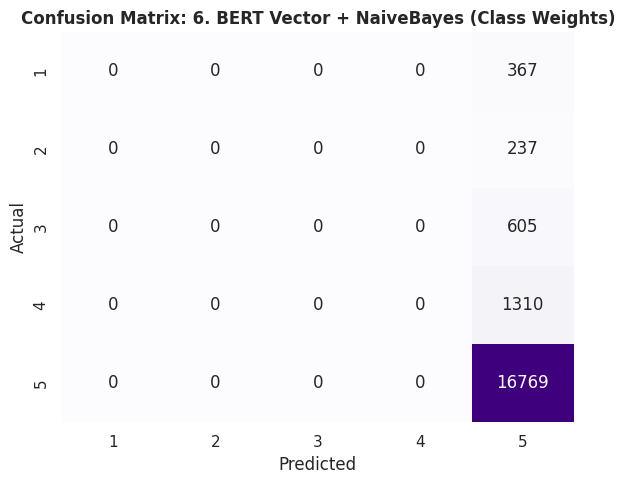

 Đã lưu tiến trình cho: 6. BERT Vector + NaiveBayes (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 7. Hybrid (TF-IDF + BERT) + LogReg (Class Weights) ]...

MODEL RESULTS: 7. Hybrid (TF-IDF + BERT) + LogReg (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.36      0.60      0.45       367
           2       0.08      0.18      0.11       237
           3       0.12      0.30      0.18       605
           4       0.15      0.37      0.21      1310
           5       0.96      0.77      0.86     16769

    accuracy                           0.72     19288
   macro avg       0.34      0.44      0.36     19288
weighted avg       0.86      0.72      0.77     19288



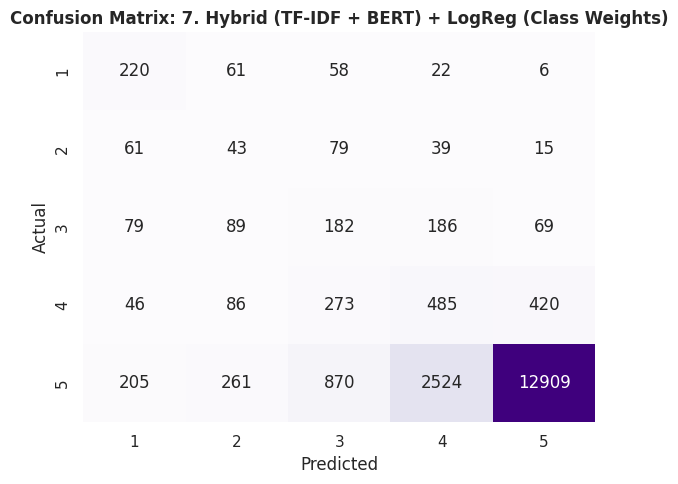

 Đã lưu tiến trình cho: 7. Hybrid (TF-IDF + BERT) + LogReg (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 8. LSTM Deep Learning (Class Weights) ]...
Epoch 1/10
2170/2170 [==============================] - 65s 26ms/step - loss: 1.3115 - accuracy: 0.6608 - val_loss: 1.0466 - val_accuracy: 0.6431
Epoch 2/10
2170/2170 [==============================] - 31s 15ms/step - loss: 1.0876 - accuracy: 0.6980 - val_loss: 0.8356 - val_accuracy: 0.6768
Epoch 3/10
2170/2170 [==============================] - 32s 15ms/step - loss: 0.9046 - accuracy: 0.7140 - val_loss: 0.6803 - val_accuracy: 0.7219
Epoch 4/10
2170/2170 [==============================] - 33s 15ms/step - loss: 0.7477 - accuracy: 0.7354 - val_loss: 0.9273 - val_accuracy: 0.6269
Epoch 5/10
2170/2170 [==============================] - 32s 15ms/step - loss: 0.6130 - accuracy: 0.7585 - val_loss: 0.8366 - val_accuracy: 0.6781
Epoch 6/10
2170/2170 [==============================] - 32s 15ms/step - loss: 0.5079 - accuracy: 0.7783 - val_loss: 0

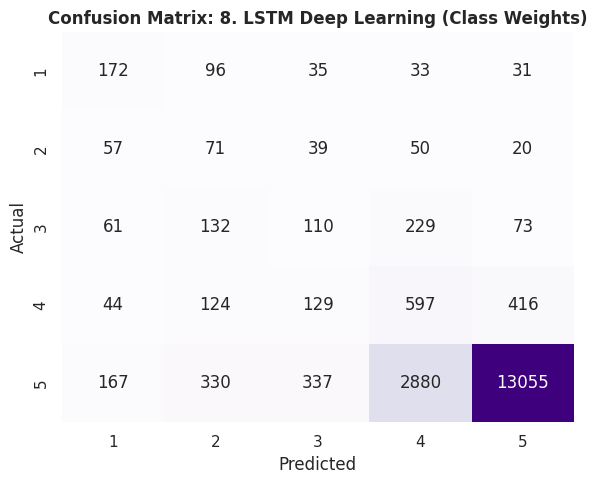

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


 Đã lưu tiến trình cho: 8. LSTM Deep Learning (Class Weights) vào file CSV.

 ĐANG HUẤN LUYỆN: [ 9. DistilBERT Fine-Tuning (Class Weights) ]...
Đang Tokenize dữ liệu cho HuggingFace...


tf_model.h5:   0%|          | 0.00/363M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at distilbert-base-uncased were not used when initializing TFDistilBertForSequenceClassification: ['vocab_projector', 'activation_13', 'vocab_transform', 'vocab_layer_norm']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-

Epoch 1/3
4340/4340 [==============================] - 1050s 235ms/step - loss: 1.1782 - accuracy: 0.7055 - val_loss: 0.7836 - val_accuracy: 0.7309
Epoch 2/3
4340/4340 [==============================] - 1007s 232ms/step - loss: 1.0048 - accuracy: 0.7267 - val_loss: 0.6348 - val_accuracy: 0.7694
Epoch 3/3
603/603 [==============================] - 71s 115ms/step

MODEL RESULTS: 9. DistilBERT Fine-Tuning (Class Weights)
--- Classification Report ---
              precision    recall  f1-score   support

           1       0.52      0.65      0.58       367
           2       0.16      0.33      0.22       237
           3       0.17      0.43      0.25       605
           4       0.18      0.36      0.24      1310
           5       0.97      0.82      0.89     16769

    accuracy                           0.77     19288
   macro avg       0.40      0.52      0.43     19288
weighted avg       0.87      0.77      0.81     19288



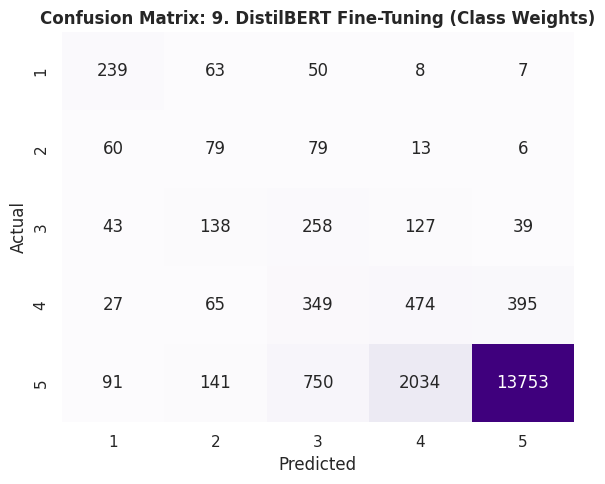

 Đã lưu tiến trình cho: 9. DistilBERT Fine-Tuning (Class Weights) vào file CSV.

 ĐÃ HOÀN THÀNH TOÀN BỘ TỔ HỢP!

 BẢNG TỔNG HỢP KẾT QUẢ CỦA TẤT CẢ CÁC TỔ HỢP:



,Tổ hợp Model,Thời gian Train (s),Thời gian Test (s),Accuracy,F1_Macro,Precision_Macro,Recall_Macro
0,9. DistilBERT Fine-Tuning (Class Weights),3084.44,73.95,0.7675,0.4341,0.4005,0.5186
1,8. LSTM Deep Learning (Class Weights),231.39,4.04,0.7261,0.3618,0.3449,0.4369
2,7. Hybrid (TF-IDF + BERT) + LogReg (Class Weig...,170.29,9.16,0.7175,0.3609,0.3350,0.4444
3,2. BoW (1-3 gram) + NaiveBayes (Class Weights),4.15,0.51,0.8290,0.3385,0.3489,0.3355
4,3. TF-IDF (1-3 gram) + LogReg (Class Weights),15.34,0.47,0.7014,0.3279,0.3056,0.4130
5,1. BoW (1-3 gram) + LogReg (Class Weights),16.31,0.46,0.7070,0.3258,0.3028,0.4096
6,5. BERT Vector + LogReg (Class Weights),175.89,7.31,0.6642,0.3156,0.2976,0.4297
7,4. TF-IDF (1-3 gram) + NaiveBayes (Class Weights),3.59,0.38,0.8549,0.3098,0.3755,0.2858
8,6. BERT Vector + NaiveBayes (Class Weights),25.46,7.42,0.8694,0.1860,0.1739,0.2000


In [35]:
import os
import time
import pandas as pd

my_class_names = sorted(np.unique(y_test))

# --- 1. SETUP FILE LƯU TIẾN TRÌNH ---
save_file = "training_checkpoint_results.csv"

if os.path.exists(save_file):
    # Nếu file đã tồn tại, đọc kết quả cũ lên
    df_results = pd.read_csv(save_file)
    results = df_results.to_dict('records')
    completed_experiments = df_results["Tổ hợp Model"].tolist()
    print(f"Tìm thấy dữ liệu cũ! Đã có {len(completed_experiments)} tổ hợp hoàn thành.")
else:
    # Nếu chạy lần đầu tiên
    results = []
    completed_experiments = []
    print("Bắt đầu chạy mới hoàn toàn.")

print(f"Tổng số tổ hợp cần huấn luyện: {len(experiments)}\n" + "="*60)

# --- 2. VÒNG LẶP HUẤN LUYỆN ---
for exp_name, pipeline in experiments.items():
    # Kiểm tra xem mô hình này đã chạy chưa
    if exp_name in completed_experiments:
        print(f"\nBỎ QUA: [ {exp_name} ] (Đã huấn luyện trước đó)")
        continue

    print(f"\n ĐANG HUẤN LUYỆN: [ {exp_name} ]...")

    # Huấn luyện
    start_time = time.time()
    pipeline.fit(df_train, y_train, df_val, y_val)
    train_time = time.time() - start_time

    # Suy luận
    start_time = time.time()
    y_pred = pipeline.predict(df_test)
    inf_time = time.time() - start_time

    # Gọi hàm vẽ Confusion Matrix và in Report
    evaluate_model(y_test, y_pred, exp_name, class_names=my_class_names)

    # Tính toán Metrics tổng hợp
    metrics = compute_comprehensive_metrics(y_test, y_pred)

    # Thêm vào danh sách kết quả
    new_result = {
        "Tổ hợp Model": exp_name,
        "Thời gian Train (s)": round(train_time, 2),
        "Thời gian Test (s)": round(inf_time, 2),
        **metrics
    }
    results.append(new_result)

    # --- SỬA Ở ĐÂY: LƯU XUỐNG Ổ CỨNG NGAY LẬP TỨC ---
    df_temp = pd.DataFrame(results)
    df_temp.to_csv(save_file, index=False)
    print(f" Đã lưu tiến trình cho: {exp_name} vào file CSV.")

# --- 3. IN BẢNG TỔNG HỢP CUỐI CÙNG ---
print("\n ĐÃ HOÀN THÀNH TOÀN BỘ TỔ HỢP!")
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by="F1_Macro", ascending=False).reset_index(drop=True)

print("\n BẢNG TỔNG HỢP KẾT QUẢ CỦA TẤT CẢ CÁC TỔ HỢP:\n")
display(df_results)

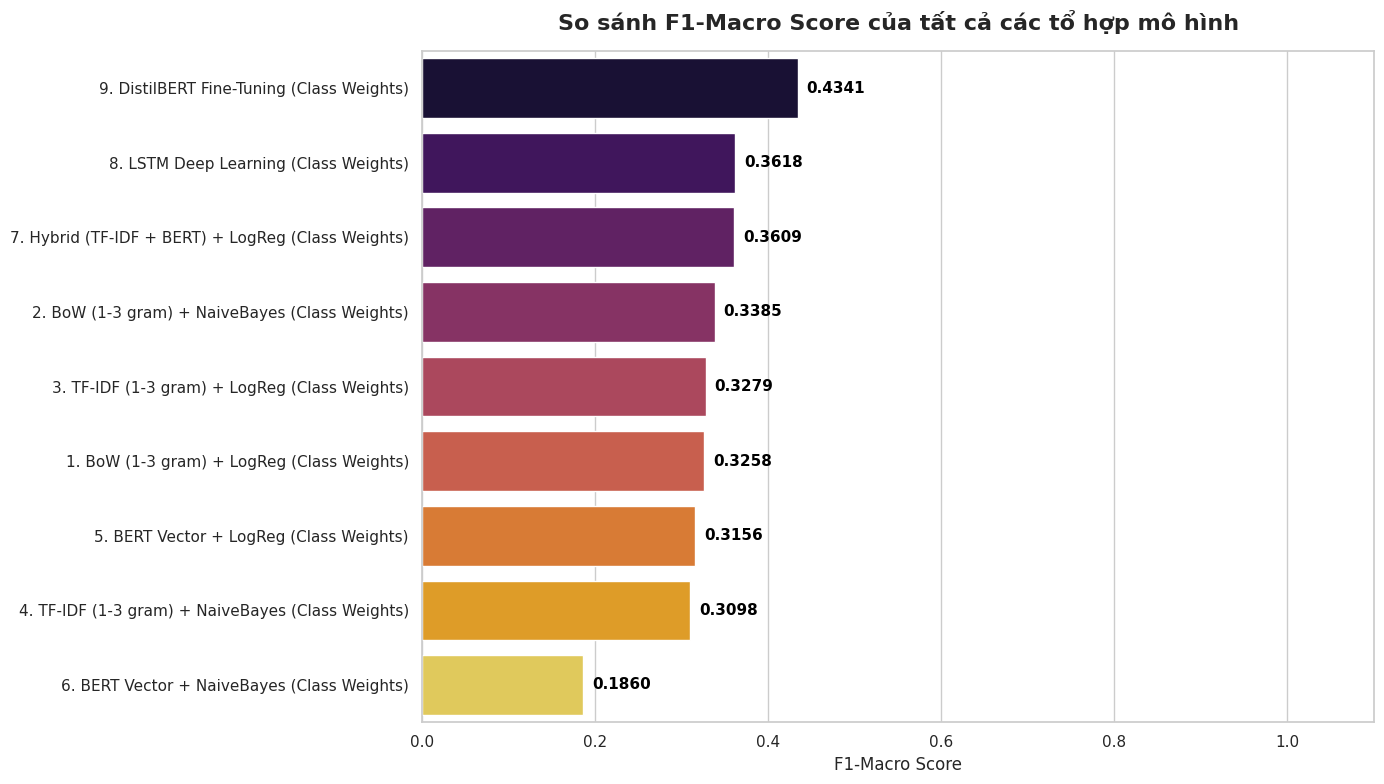

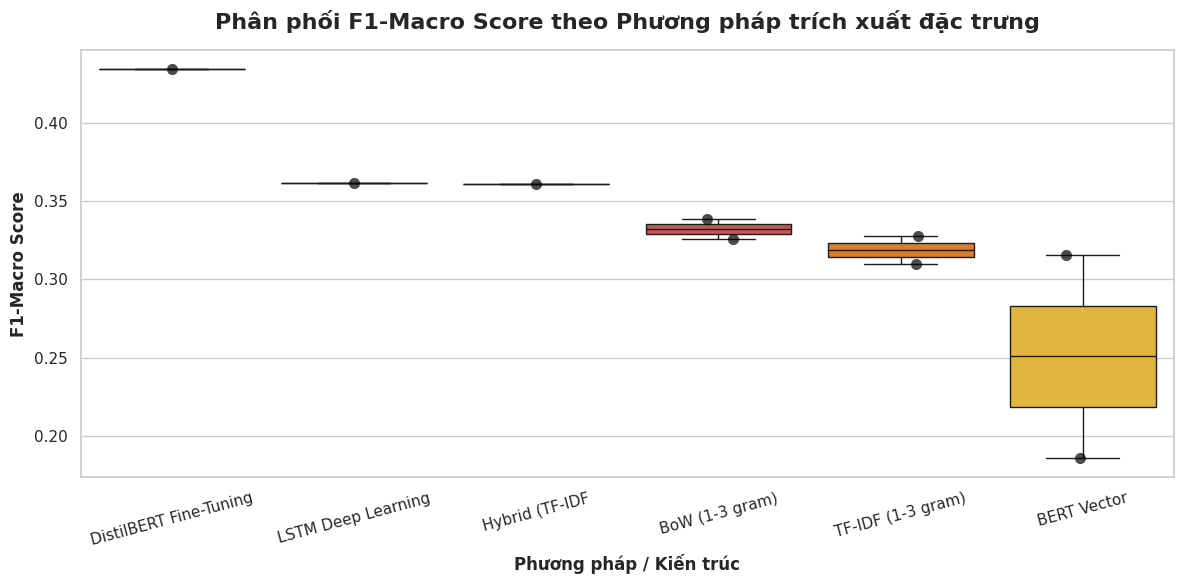

In [37]:
import re

# Thiết lập style đồ thị cho đẹp mắt
sns.set_theme(style="whitegrid")

# =====================================================================
# 1. BAR PLOT: So sánh F1-Macro Score của tất cả các tổ hợp
# =====================================================================
plt.figure(figsize=(14, 8))

# Đổi palette sang 'inferno'
ax = sns.barplot(
    data=df_results,
    x='F1_Macro',
    y='Tổ hợp Model',
    palette='inferno'
)

plt.title('So sánh F1-Macro Score của tất cả các tổ hợp mô hình', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('F1-Macro Score', fontsize=12)
plt.ylabel('', fontsize=12) # Ẩn tên trục y cho gọn
plt.xlim(0, 1.1) # Mở rộng trục x một chút để có chỗ in text

# Gắn số liệu cụ thể lên từng thanh bar
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f'{width:.4f}',
        ha='left',
        va='center',
        fontsize=11,
        color='black',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


# =====================================================================
# 2. XỬ LÝ DỮ LIỆU ĐỂ VẼ BOX PLOT
# =====================================================================
def extract_feature_method(exp_name):
    """
    Hàm cắt bỏ số thứ tự ở đầu và trích xuất phương pháp đặc trưng/kiến trúc.
    VD: '1. BoW (1-3 gram) + LogReg...' -> 'BoW (1-3 gram)'
    VD: '8. LSTM Deep Learning...' -> 'LSTM Deep Learning'
    """
    # Xóa số thứ tự (VD: "1. ")
    name = re.sub(r'^\d+\.\s*', '', exp_name)

    # Nếu là ML truyền thống (có dấu +)
    if ' + ' in name:
        return name.split(' + ')[0].strip()
    # Nếu là Deep Learning (lấy phần trước dấu ngoặc đơn)
    else:
        return name.split(' (')[0].strip()

# Tạo cột mới chứa tên nhóm phương pháp
df_results['Nhóm phương pháp'] = df_results['Tổ hợp Model'].apply(extract_feature_method)


# =====================================================================
# 3. BOX PLOT: Phân phối F1-score giữa các phương pháp trích xuất
# =====================================================================
plt.figure(figsize=(12, 6))

# Vẽ Boxplot chính, đổi palette sang 'inferno'
sns.boxplot(
    data=df_results,
    x='Nhóm phương pháp',
    y='F1_Macro',
    palette='inferno',
    showfliers=False # Tắt các điểm ngoại lai của boxplot vì ta sẽ vẽ stripplot đè lên
)

# Chấm thêm các điểm tròn (stripplot) thể hiện từng mô hình cụ thể bên trong Box
sns.stripplot(
    data=df_results,
    x='Nhóm phương pháp',
    y='F1_Macro',
    color='black',
    alpha=0.7,
    size=8,
    jitter=True
)

plt.title('Phân phối F1-Macro Score theo Phương pháp trích xuất đặc trưng', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Phương pháp / Kiến trúc', fontsize=12, fontweight='bold')
plt.ylabel('F1-Macro Score', fontsize=12, fontweight='bold')
plt.xticks(rotation=15) # Nghiêng nhãn trục x một chút nếu tên quá dài

plt.tight_layout()
plt.show()